In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy import sparse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load processed test data
X_test = sparse.load_npz("X_test_processed.npz")
y_test = pd.read_csv("y_test.csv").squeeze()

# Load final model
model = joblib.load(r"Models\xgboost_regression_model.pkl")

# Make predictions
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of test observations:", len(y_test))

Predictions generated successfully.
Number of test observations: 3124


In [ ]:
model = joblib.load(r"Models\xgboost_regression_model.pkl")

In [ ]:
error_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Prediction error
error_df["Error"] = error_df["Predicted"] - error_df["Actual"]

# Absolute error
error_df["Absolute_Error"] = abs(error_df["Error"])

# Squared error
error_df["Squared_Error"] = error_df["Error"] ** 2

print(error_df.head(10))

      Actual  Predicted     Error  Absolute_Error  Squared_Error
0  17.573222  13.227513 -4.345708        4.345708      18.885182
1  11.982743  10.041887 -1.940855        1.940855       3.766920
2  22.420901  20.064196 -2.356705        2.356705       5.554059
3  25.951557  25.483906 -0.467651        0.467651       0.218698
4  25.789474  25.483906 -0.305568        0.305568       0.093372
5   4.411765   5.334914  0.923149        0.923149       0.852204
6   3.150242   5.070120  1.919878        1.919878       3.685930
7   9.509202  10.810621  1.301419        1.301419       1.693691
8   5.810928   5.940954  0.130026        0.130026       0.016907
9   2.321347   1.984012 -0.337336        0.337336       0.113795


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("ERROR ANALYSIS")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

ERROR ANALYSIS
-------------------------
MAE  : 1.8337
RMSE : 2.8405
R²   : 0.9652


In [ ]:
largest_errors = error_df.sort_values(
    "Absolute_Error",
    ascending=False
)

print("10 largest prediction errors:")
print(largest_errors.head(10))

10 largest prediction errors:
         Actual  Predicted      Error  Absolute_Error  Squared_Error
1877   3.980100  30.262854  26.282754       26.282754     690.783164
2098  33.333333   7.502887 -25.830446       25.830446     667.211945
2689   2.487562  23.243814  20.756252       20.756252     430.822009
2875  23.383085  39.184181  15.801097       15.801097     249.674655
1768  78.723404  63.356400 -15.367005       15.367005     236.144834
2463  32.773852  17.625494 -15.148358       15.148358     229.472738
1134  32.822086  19.056185 -13.765901       13.765901     189.500034
1862  11.732852  25.364235  13.631383       13.631383     185.814601
2217  41.212121  27.744049 -13.468072       13.468072     181.388967
1863  13.836478  27.248522  13.412044       13.412044     179.882919


In [ ]:
largest_errors.head(20).to_csv(
    "largest_prediction_errors.csv",
    index=False
)

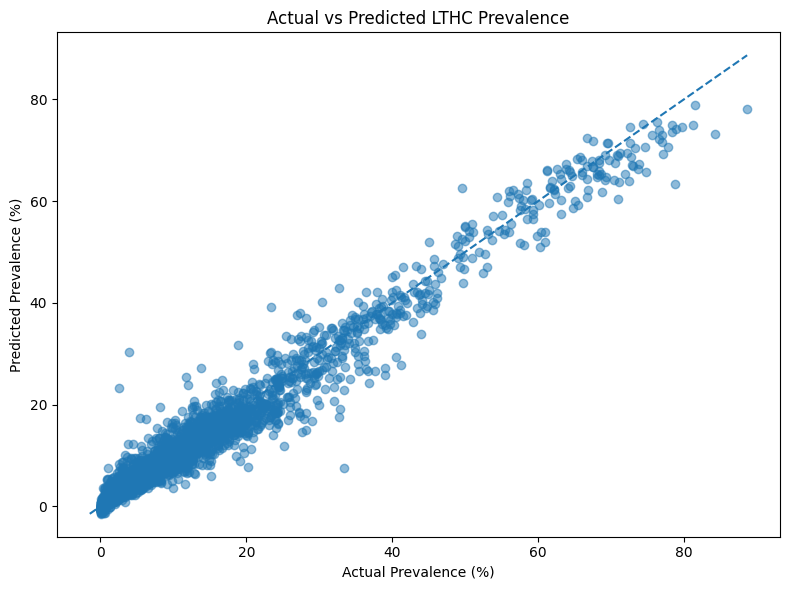

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_df["Actual"],
    error_df["Predicted"],
    alpha=0.5
)

# Perfect prediction line
min_value = min(error_df["Actual"].min(), error_df["Predicted"].min())
max_value = max(error_df["Actual"].max(), error_df["Predicted"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Prevalence (%)")
plt.ylabel("Predicted Prevalence (%)")
plt.title("Actual vs Predicted LTHC Prevalence")

plt.tight_layout()
plt.show()

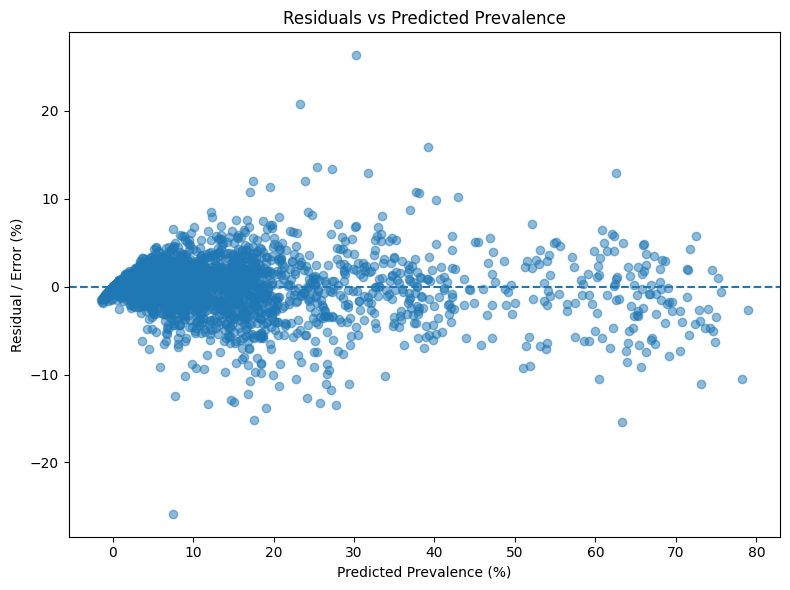

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_df["Predicted"],
    error_df["Error"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Prevalence (%)")
plt.ylabel("Residual / Error (%)")
plt.title("Residuals vs Predicted Prevalence")

plt.tight_layout()
plt.show()

In [ ]:
error_df["Actual_Range"] = pd.cut(
    error_df["Actual"],
    bins=[-np.inf, 5, 10, 20, 50, 100],
    labels=[
        "0–5%",
        "5–10%",
        "10–20%",
        "20–50%",
        "50–100%"
    ]
)

range_error = error_df.groupby(
    "Actual_Range",
    observed=True
)["Absolute_Error"].agg(
    ["count", "mean", "median", "max"]
)

print(range_error)

              count      mean    median        max
Actual_Range                                      
0–5%           1254  0.944197  0.609035  26.282754
5–10%           639  1.505952  1.124486  11.946476
10–20%          656  2.216496  1.737355  13.631383
20–50%          438  3.720926  2.878537  25.830446
50–100%         137  3.636578  2.963137  15.367005


In [ ]:
over_predictions = (error_df["Error"] > 0).sum()
under_predictions = (error_df["Error"] < 0).sum()
accurate_predictions = (error_df["Error"] == 0).sum()

print("Overpredictions :", over_predictions)
print("Underpredictions:", under_predictions)
print("Exact predictions:", accurate_predictions)
total = len(error_df)

print(f"Overprediction percentage: {over_predictions / total * 100:.2f}%")
print(f"Underprediction percentage: {under_predictions / total * 100:.2f}%")

Overpredictions : 1689
Underpredictions: 1435
Exact predictions: 0
Overprediction percentage: 54.07%
Underprediction percentage: 45.93%
